# SHAMe noise parameters from NPE posterior

**Goal:** For the SHAMe out-of-distribution (OOD) mock, estimate how the **multiplicative noise amplitudes** would look *if we already knew* certain cosmology and bias parameters — i.e. **profile / conditional 1D marginals** of the trained NPE posterior.

**Workflow (cells below):**
1. **Config** — same training tags as `2026-04-22_inference_SHAMe_best-rand30.ipynb` (pk+bispec+pgm, `_kb0.25`, `best-rand30`).
2. **Load** — trained posterior + scaled SHAMe data vector `x`; truth cosmo/bias in **reparameterized** coordinates (what the network sees).
3. **MAP** — marginal modes from saved posterior *samples* (for bias in scenario 2, and to pin the *other* noise params during each 1D sweep).
4. **Sweep** — for each noise parameter, build $p(\theta_{\mathrm{noise},i} \mid \text{fixed cosmo/bias}, \text{other noise at MAP}, x)$ on a grid.
5. **Plot** — compare two conditioning choices side by side.

**Two conditioning scenarios:**

| Scenario | Fixed parameters |
|----------|------------------|
| Truth cosmo + truth bias | SHAMe OOD truth ($\Omega_c$, $\sigma_8$, $b_i$) |
| Truth cosmo + MAP bias | Truth $\Omega_c$, $\sigma_8$; bias from 1D MAP of posterior samples |

**Two computational methods** (`CONDITIONAL_METHOD`):
- **`log_prob`** — evaluate `posterior.log_prob` on a grid, subtract log-partition function → exact conditional (needs GPU).
- **`samples`** — reweight saved posterior samples with narrow Gaussians on fixed dims → fast histogram (default on CPU).

**Reparameterization:** The NPE was trained on `_rp` coordinates: biases and most noise enter as products with $\sigma_8$ (e.g. `sigma8_cold_x_b1`). This notebook sweeps and plots in **physical** noise units (`An_homog`, `An_b1`, …) by dividing out $\sigma_8$ factors where needed.

See also: `2026-04-22_inference_SHAMe_best-rand30.ipynb`.

In [1]:
# Import torch *before* adding repo/code to sys.path (folder name "code" shadows stdlib).
import pickle
import sys
from pathlib import Path

import numpy as np
import torch
from matplotlib import pyplot as plt

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import data_loader       # load OOD mocks + truth parameters
import generate_params as genp  # prior bounds on noise
import utils_inference   # reparameterization, samples, MAP
import utils_model       # ordered parameter name lists
import utils_plot        # build inference / test tags
import paths             # DIR_RESULTS → saved SBI artifacts

%load_ext autoreload
%autoreload 2


In [2]:
# --- Configuration (aligned with 2026-04-22_inference_SHAMe_best-rand30) ---

# Training run metadata (encoded in posterior directory tag)
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"  # best-of-random-30 checkpoint

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN_NOISY = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"  # network uses reparameterized θ

# Summary statistics fed to the NPE (concatenated along last axis)
STATISTICS = ["pk", "bispec", "pgm"]
# k-space masks per statistic; bispec uses k < 0.25 h/Mpc → tag contains `_kb0.25`
TAGS_MASK_PER_STAT = ["", "_kb0.25", ""]
TAG_MASK_JOINED = "".join(TAGS_MASK_PER_STAT)
tags_mask_inf = [TAG_MASK_JOINED]

# SHAMe OOD mock: middle number density in utils_model.bias_dict_shame
TAG_MOCK_SHAME = "_nbar0.00022"
DATA_MODE_TEST_SHAME = "shame"

# Grid resolution for each 1D noise marginal
N_GRID = 128
LOG_PROB_BATCH_SIZE = 2048  # batched log_prob calls (one sweep fits in one batch when N_GRID ≤ this)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# How to evaluate conditionals:
#   "log_prob" — exact via neural posterior (slow on CPU)
#   "samples"  — reweighted histogram from saved chains (fast)
#   "auto"     — log_prob on CUDA, samples on CPU
CONDITIONAL_METHOD = "auto"
SAMPLE_WEIGHT_TOL_FRAC = 0.12  # Gaussian σ on fixed dims = this × posterior std (samples method only)

ANOISE_OPTION = "Anmult"  # multiplicative noise; sets prior bounds via genp.get_bounds

# Parameter subsets (physical names before reparameterization)
COSMO_PARAM_NAMES_VARY = list(utils_model.cosmo_param_names_ordered[:2])  # omega_cold, sigma8_cold
BIAS_PARAM_NAMES_VARY = list(utils_model.biasparam_names_ordered)
NOISE_PHYS_NAMES = list(utils_model.noiseparam_names_ordered)  # An_homog, An_b1, ...

In [ ]:
# --- Notebook-local helper: one 1D conditional noise marginal ---
#
# Target: p(noise_i | fixed cosmo & bias, other noise_j≠i at MAP, observed x).
# The NPE gives log p(θ | x) for full 11-D θ in reparam space; we profile one
# noise dimension at a time by holding everything else fixed.


def eval_conditional_noise_1d(
    method,
    posterior,
    x_batch,
    samples,
    param_names,
    fixed_rp,
    noise_phys,
    other_noise_rp,
    bounds_noise,
    n_grid=N_GRID,
):
    """One profile conditional over a single physical noise parameter.

    fixed_rp: reparam dict for cosmo+bias held fixed in this scenario.
    noise_phys: e.g. "An_b1" — swept coordinate (physical units on plot).
    other_noise_rp: other noise params pinned at MAP (reparam coords).
    """
    lo, hi = bounds_noise[noise_phys]
    grid = np.linspace(lo, hi, n_grid)  # physical units for plotting
    sigma8 = fixed_rp["sigma8_cold"]  # convert reparam ↔ physical noise

    if method == "samples":
        # Fast approx: reweight saved posterior samples near the fixed θ values.
        fixed_all = {**other_noise_rp, **fixed_rp}
        w = np.ones(len(samples))
        for pn, target in fixed_all.items():
            col = samples[:, param_names.index(pn)]
            tol = max(float(np.std(col)) * SAMPLE_WEIGHT_TOL_FRAC, 1e-8)
            w *= np.exp(-0.5 * ((col - target) / tol) ** 2)
        w /= w.sum()
        # Swept coordinate in physical units
        if noise_phys == "An_homog":
            col_phys = samples[:, param_names.index("An_homog")]
        else:
            cn = utils_inference.reparameterized_sample_name(noise_phys)
            scale = sigma8 ** 2 if noise_phys in utils_inference.PARAMS_SIGMA8_SQUARED_MULT else sigma8
            col_phys = samples[:, param_names.index(cn)] / scale
        counts, _ = np.histogram(col_phys, bins=n_grid, range=(lo, hi), weights=w)
        logp = np.log(counts + 1e-300)

    else:
        # Exact: grid of full θ in reparam space → log_prob → renormalize over grid.
        if noise_phys == "An_homog":
            sweep_col, grid_col = "An_homog", grid
        else:
            sweep_col = utils_inference.reparameterized_sample_name(noise_phys)
            scale = sigma8 ** 2 if noise_phys in utils_inference.PARAMS_SIGMA8_SQUARED_MULT else sigma8
            grid_col = grid * scale  # reparam = physical × σ8 or σ8²
        n = len(grid_col)
        rows = np.empty((n, len(param_names)), dtype=np.float32)
        for j, pn in enumerate(param_names):
            if pn in other_noise_rp:
                rows[:, j] = other_noise_rp[pn]
            if pn in fixed_rp:
                rows[:, j] = fixed_rp[pn]
        rows[:, param_names.index(sweep_col)] = grid_col.astype(np.float32)
        logp = []
        with torch.inference_mode():
            for start in range(0, n, LOG_PROB_BATCH_SIZE):
                chunk = torch.as_tensor(rows[start : start + LOG_PROB_BATCH_SIZE], device=x_batch.device)
                logp.append(posterior.log_prob(chunk, x=x_batch).detach().cpu().numpy())
        logp = np.concatenate(logp)

    # log p(θ_i | fixed, x) ∝ log p(θ | x) with other dims fixed
    logp_norm = logp - np.logaddexp.reduce(logp)
    w = np.exp(logp_norm - np.max(logp_norm))
    w /= w.sum()
    return dict(
        grid=grid,
        log_prob=logp,
        log_prob_norm=logp_norm,
        map_phys=float(grid[np.argmax(logp_norm)]),
        mean_phys=float(np.sum(w * grid)),
    )


In [4]:
# --- Load trained posterior, SHAMe observation x, and truth cosmo/bias ---

# Build directory tags (must match files under results/results_sbi/)
tags_inf, labels_inf, colors_inf, tag_stats_arr = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=[STATISTICS],
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_inf,
)
tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
tag_test = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=tag_stats_arr,
    tag_mock=TAG_MOCK_SHAME,
    data_mode_test=DATA_MODE_TEST_SHAME,
    tags_mask=tags_mask_inf,
)[0]
print("tag_inf:", tag_inf)
print("tag_test:", tag_test)

# Neural posterior + per-statistic scalers (same as at inference time)
dir_sbi = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf}"
with open(dir_sbi / "posterior.p", "rb") as f:
    posterior = pickle.load(f)
posterior.posterior_estimator.to(DEVICE).eval()
param_names = list(np.loadtxt(dir_sbi / "param_names.txt", dtype=str))
scalers = {s: pickle.load(open(dir_sbi / f"scaler_y_{s}.p", "rb")) for s in STATISTICS}

# Observed summary statistics for this SHAMe mock (masked pk, bispec, pgm → 114 bins)
_k, y_list, _ = data_loader.load_data_ood(
    DATA_MODE_TEST_SHAME, STATISTICS, TAG_MOCK_SHAME, tags_mask=TAGS_MASK_PER_STAT
)
x_batch = torch.as_tensor(
    np.concatenate([scalers[s].scale(y) for s, y in zip(STATISTICS, y_list)], axis=-1),
    dtype=torch.float32,
    device=DEVICE,
).unsqueeze(0)  # shape (1, n_bins) for sbi
print("device:", DEVICE, "x shape:", tuple(x_batch.shape))

# Truth cosmo + bias in physical coords → reparam (what the network expects)
names_phys = COSMO_PARAM_NAMES_VARY + BIAS_PARAM_NAMES_VARY
theta_phys = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME, COSMO_PARAM_NAMES_VARY, BIAS_PARAM_NAMES_VARY
)
theta_rp, names_rp = utils_inference.reparameterize_theta(theta_phys, names_phys)
fixed_truth_rp = dict(zip(names_rp, map(float, theta_rp)))
print("truth (posterior coords):", {k: round(v, 5) for k, v in fixed_truth_rp.items()})
# Noise truth is NOT fixed here — we sweep noise in later cells.


tag_inf: _muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30
tag_test: _shame_pk_bispec_pgm_kb0.25_nbar0.00022


2026-05-27 20:44:13.596694: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 20:44:13.697618: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-27 20:44:13.697663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-27 20:44:13.709782: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-27 20:44:13.738390: I tensorflow/core/platform/cpu_feature_guar

Loaded pk with shape (32,)
Loaded pk data with shape (32,)
Masked 0 out of 32 bins
Loaded bispec with shape (203,)
Loaded bispec data with shape (203,)
Masked 153 out of 203 bins
Loaded pgm with shape (32,)
Loaded pgm data with shape (32,)
Masked 0 out of 32 bins
device: cpu
param_names: ['omega_cold', 'sigma8_cold', 'sigma8_cold_x_b1', 'sigma8_cold_sq_x_b2', 'sigma8_cold_sq_x_bs2', 'sigma8_cold_x_bl', 'An_homog', 'sigma8_cold_x_An_b1', 'sigma8_cold_sq_x_An_b2', 'sigma8_cold_sq_x_An_bs2', 'sigma8_cold_x_An_bl']
x shape: (1, 114)
truth (posterior coords): {'omega_cold': 0.3089, 'sigma8_cold': 0.8159, 'sigma8_cold_x_b1': 0.38682, 'sigma8_cold_sq_x_b2': 0.08455, 'sigma8_cold_sq_x_bs2': -0.22555, 'sigma8_cold_x_bl': -0.67266}


In [5]:
# --- MAP from saved posterior samples (scenario 2 + pinning other noise) ---

# Pre-computed test samples: p(θ | x_SHAMe) from the main inference notebook
samples, param_names_chain = utils_inference.get_samples_sbi(0, tag_inf, tag_test=tag_test)
map_all = dict(zip(param_names, utils_inference.get_posterior_maxes(samples, param_names)))

# 11-D parameter split: cosmo+bias block vs noise block (reparam coords)
noise_rp_names = [n for n in param_names if n == "An_homog" or "_An_" in n]
bias_rp_names = [n for n in param_names if n not in noise_rp_names]

# Scenario 2: truth Ω_c, σ_8; replace bias with 1D MAP from samples
fixed_mapbias_rp = {**fixed_truth_rp, **{pn: map_all[pn] for pn in bias_rp_names if pn not in ("omega_cold", "sigma8_cold")}}

print("MAP bias (reparam):", {k: round(map_all[k], 5) for k in bias_rp_names if k not in ("omega_cold", "sigma8_cold")})
print("reference noise at MAP (reparam):", {k: round(map_all[k], 5) for k in noise_rp_names})
# During each 1D sweep, the *other* noise parameters stay at these MAP values.


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
MAP bias (reparam): {'sigma8_cold_x_b1': 0.377, 'sigma8_cold_sq_x_b2': -0.04425, 'sigma8_cold_sq_x_bs2': 0.13523, 'sigma8_cold_x_bl': 1.58306}
reference noise at MAP (reparam): {'An_homog': -1.00516, 'sigma8_cold_x_An_b1': 0.21928, 'sigma8_cold_sq_x_An_b2': 0.02011, 'sigma8_cold_sq_x_An_bs2': 2.00681, 'sigma8_cold_x_An_bl': 0.44401}


## 1D conditional marginals \(p(\theta_{\mathrm{noise},i} \mid \mathrm{fixed}, x)\)

For each physical noise parameter \(i\), we compute a **profile conditional**:

\[
p(\theta_{\mathrm{noise},i} \mid \theta_{\mathrm{cosmo,bias}}^{\mathrm{fixed}},\; \theta_{\mathrm{noise},j\neq i}^{\mathrm{MAP}},\; x)
\]

- **Cosmo + bias** fixed per scenario (truth vs truth+MAP bias).
- **Other noise** \(j \neq i\) fixed at marginal MAP from samples (not jointly optimized).
- Swept coordinate plotted in **physical** multiplicative units.

Methods: see intro; `eval_conditional_noise_1d` implements both.

In [6]:
# --- Sweep all five noise parameters × two conditioning scenarios ---

if CONDITIONAL_METHOD == "auto":
    method = "log_prob" if DEVICE.type == "cuda" else "samples"
else:
    method = CONDITIONAL_METHOD

bounds_noise = genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION)  # grid endpoints from prior
other_noise_ref = {n: map_all[n] for n in noise_rp_names}  # pin non-swept noise at MAP

scenarios = {
    "truth cosmo+bias": fixed_truth_rp,
    "truth cosmo + MAP bias": fixed_mapbias_rp,
}
print(f"conditional method: {method} (device={DEVICE}, N_GRID={N_GRID})")

results = {}  # results[scenario][noise_phys] → dict from eval_conditional_noise_1d
for scen_name, fixed_rp in scenarios.items():
    results[scen_name] = {}
    print(f"\n=== {scen_name} ===")
    for noise_phys in NOISE_PHYS_NAMES:
        sweep_col = "An_homog" if noise_phys == "An_homog" else utils_inference.reparameterized_sample_name(noise_phys)
        other = {k: v for k, v in other_noise_ref.items() if k != sweep_col}  # exclude swept column
        r = eval_conditional_noise_1d(
            method, posterior, x_batch, samples, param_names,
            fixed_rp, noise_phys, other, bounds_noise,
        )
        results[scen_name][noise_phys] = r
        print(f"  {noise_phys:8s}  MAP={r['map_phys']:+.3f}  mean={r['mean_phys']:+.3f}")


conditional method: samples (device=cpu, N_GRID=128)

=== truth cosmo+bias ===
  An_homog  MAP=+0.260  mean=-0.123  (0.0s)
  An_b1     MAP=+0.449  mean=+0.075  (0.0s)
  An_b2     MAP=-0.394  mean=-0.006  (0.0s)
  An_bs2    MAP=-1.614  mean=+0.192  (0.0s)
  An_bl     MAP=+0.551  mean=+0.292  (0.0s)

=== truth cosmo + MAP bias ===
  An_homog  MAP=+1.110  mean=+1.110  (0.0s)
  An_b1     MAP=+1.535  mean=+1.535  (0.0s)
  An_b2     MAP=-1.307  mean=-1.307  (0.0s)
  An_bs2    MAP=+0.039  mean=+0.033  (0.0s)
  An_bl     MAP=-7.323  mean=-7.300  (0.0s)

Total: 0.0s


In [9]:
# --- Tabular summary: MAP and mean of each conditional marginal ---

for scen_name in scenarios:
    for noise_phys in NOISE_PHYS_NAMES:
        r = results[scen_name][noise_phys]
        print(
            f"{scen_name:28s} {noise_phys:8s} {r['map_phys']:8.3f} {r['mean_phys']:8.3f} "
            f"(truth-fixed MAP {results['truth cosmo+bias'][noise_phys]['map_phys']:+.3f})"
        )
# Last column: MAP under truth cosmo+bias (reference scenario for comparison).


scenario                     param         MAP     mean
------------------------------------------------------------
truth cosmo+bias             An_homog    0.260   -0.123
truth cosmo+bias             An_b1       0.449    0.075
truth cosmo+bias             An_b2      -0.394   -0.006
truth cosmo+bias             An_bs2     -1.614    0.192
truth cosmo+bias             An_bl       0.551    0.292
truth cosmo + MAP bias       An_homog    1.110    1.110
truth cosmo + MAP bias       An_b1       1.535    1.535
truth cosmo + MAP bias       An_b2      -1.307   -1.307
truth cosmo + MAP bias       An_bs2      0.039    0.033
truth cosmo + MAP bias       An_bl      -7.323   -7.300


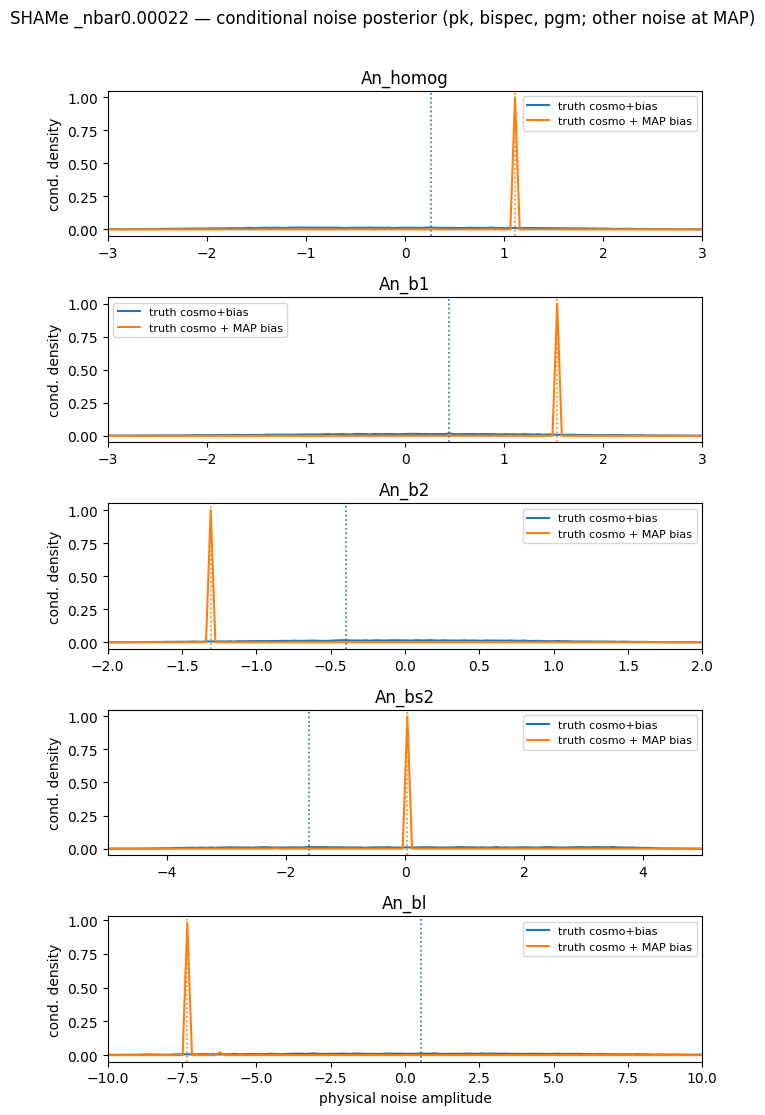

In [10]:
# --- Plot normalized 1D conditionals: exp(log_prob_norm) on physical grid ---

fig, axes = plt.subplots(len(NOISE_PHYS_NAMES), 1, figsize=(7, 2.2 * len(NOISE_PHYS_NAMES)), sharex=False)
if len(NOISE_PHYS_NAMES) == 1:
    axes = [axes]

colors = {"truth cosmo+bias": "C0", "truth cosmo + MAP bias": "C1"}

for ax, noise_phys in zip(axes, NOISE_PHYS_NAMES):
    for scen_name in scenarios:
        r = results[scen_name][noise_phys]
        ax.plot(r["grid"], np.exp(r["log_prob_norm"]), color=colors[scen_name], label=scen_name)
        ax.axvline(r["map_phys"], color=colors[scen_name], ls=":", lw=1.2)  # profile MAP
    lo, hi = bounds_noise[noise_phys]
    ax.set_xlim(lo, hi)
    ax.set_ylabel("cond. density")
    ax.set_title(noise_phys)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("physical noise amplitude")
fig.suptitle(
    f"SHAMe {TAG_MOCK_SHAME} — conditional noise posterior ({', '.join(STATISTICS)}; other noise at MAP)",
    y=1.01,
)
fig.tight_layout()
plt.show()

## Optional: compare to *marginal* noise from full posterior samples

The profile conditionals above fix cosmo, bias, and other noise. The **marginal** over one noise coordinate from the full joint sample (no conditioning) is different — run the cell below only as a sanity check.

In [11]:
# Compare: marginal from full joint samples vs profile MAP (truth cosmo+bias scenario)
for i, noise_phys in enumerate(NOISE_PHYS_NAMES):
    col = utils_inference.reparameterized_sample_name(noise_phys) or noise_phys
    j = param_names.index(col if col in param_names else noise_phys)
    vals = samples[:, j]
    if noise_phys != "An_homog":
        vals = vals / (samples[:, param_names.index("sigma8_cold")] ** (2 if noise_phys in utils_inference.PARAMS_SIGMA8_SQUARED_MULT else 1))
    print(noise_phys, "sample median", np.median(vals), "profile MAP (truth fixed)", results["truth cosmo+bias"][noise_phys]["map_phys"])

An_homog sample median -0.15931481 profile MAP (truth fixed) 0.25984251968503935
An_b1 sample median 0.10607107 profile MAP (truth fixed) 0.44881889763779537
An_b2 sample median -0.0003030356 profile MAP (truth fixed) -0.39370078740157477
An_bs2 sample median 0.24541126 profile MAP (truth fixed) -1.614173228346457
An_bl sample median 0.4340843 profile MAP (truth fixed) 0.5511811023622037
